In [ ]:
install.packages("viridis")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
#LIBRERIAS
library(ggplot2)
library(tidyr)
library(dplyr)
library(readr)
library(viridis)


# Ejercicio 2

In [ ]:
#LECTURA DEL ARCHIVO
df <- read_csv("inegi.csv.CSV", show_col_types = FALSE)

df <- df %>%
  mutate(
    fn_dia = as.integer(fn_dia),
    fn_mes = as.integer(fn_mes)
  )

In [ ]:
#CONTEO DE VALORES UNICOS
for (key in colnames(df)) {
  print(paste0(key, ": ", length(unique(df[[key]])), " valores únicos"))
}

[1] "estado: 32 valores únicos"
[1] "llave: 232057 valores únicos"
[1] "fn_dia: 32 valores únicos"
[1] "fn_mes: 13 valores únicos"


In [ ]:
unique(df["fn_dia"])


fn_dia
<int>
18
12
22
24
26
19
7
31
16


In [ ]:
unique(df["fn_mes"])

fn_mes
<int>
10
5
7
6
4
9
8
2
3


In [ ]:
df <- filter(df, fn_dia != 99, fn_mes != 99)

In [ ]:
df<-drop_na(df)

In [ ]:
df

estado,llave,fn_dia,fn_mes
<chr>,<chr>,<int>,<int>
01,01000501101,18,10
01,01000501102,12,5
01,01000501103,22,7
01,01000503101,24,10
01,01000503102,26,10
01,01000503103,19,6
01,01000504101,7,10
01,01000504102,18,5
01,01000505101,31,7


In [ ]:
df <- df %>% mutate(dia_del_año = as.integer(format(as.Date(paste(2025, fn_mes, fn_dia, sep = "-"), format="%Y-%m-%d"), "%j")))

df


estado,llave,fn_dia,fn_mes,dia_del_año
<chr>,<chr>,<int>,<int>,<int>
01,01000501101,18,10,291
01,01000501102,12,5,132
01,01000501103,22,7,203
01,01000503101,24,10,297
01,01000503102,26,10,299
01,01000503103,19,6,170
01,01000504101,7,10,280
01,01000504102,18,5,138
01,01000505101,31,7,212


In [ ]:
nombres <- read_csv("catalogo_entidades.csv", show_col_types = FALSE)


In [ ]:
#SE HACE UN MERGE CON AL DF PRINCIPAL
df <- merge(df, nombres,
            by.x = "estado",
            by.y = "CLAVE ENTIDAD",
            all.x = TRUE)

names(df)[names(df) == "NOMBRE ENTIDAD"] <- "Nombre_estado"

In [ ]:
df

estado,llave,fn_dia,fn_mes,dia_del_año,Nombre_estado
<chr>,<chr>,<int>,<int>,<int>,<chr>
01,01000501101,18,10,291,Aguascalientes
01,01000501102,12,5,132,Aguascalientes
01,01000501103,22,7,203,Aguascalientes
01,01000503101,24,10,297,Aguascalientes
01,01000503102,26,10,299,Aguascalientes
01,01000503103,19,6,170,Aguascalientes
01,01000504101,7,10,280,Aguascalientes
01,01000504102,18,5,138,Aguascalientes
01,01000505101,31,7,212,Aguascalientes


In [ ]:
df<-drop_na(df)

In [ ]:
months = c("Ene","Feb","Mar","Abr","May","Jun", "Jul","Ago","Sep","Oct","Nov","Dic")
days_by_month = c(31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31)

#ETIQUETA DE MESES
month_positions <- cumsum(days_by_month) - days_by_month / 2
month_positions <- month_positions[1:12]


#DELIMITADORES
month_divisions <- cumsum(days_by_month)
month_divisions <- month_divisions[-length(month_divisions)]

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


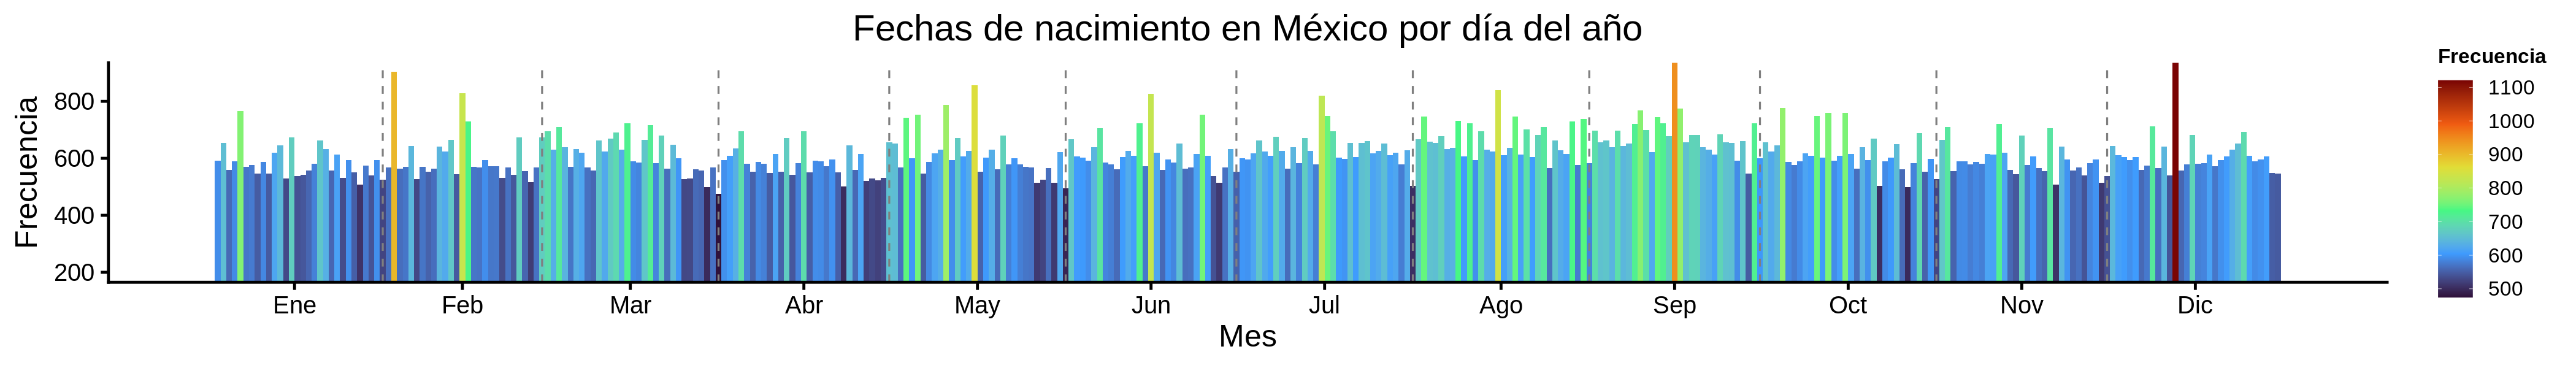

In [ ]:
options(repr.plot.width = 35, repr.plot.height = 5)

grafico <- df %>%
  ggplot(aes(x = dia_del_año, fill = after_stat(count))) +
  geom_histogram(alpha = 1, bins = 365, color = NA) +
  scale_fill_viridis_c(option = "turbo", name = "Frecuencia") +
  scale_x_continuous(
    breaks = month_positions,
    labels = months,
    limits = c(1, 365)
  ) + geom_vline(xintercept = month_divisions, color = "gray50", linewidth = 0.9, linetype = "dashed") +
  labs(title = "Fechas de nacimiento en México por día del año",
       x = "Mes",
       y = "Frecuencia") +
  theme_classic(base_size = 30) +
    coord_cartesian(ylim = c(200, 900)) +
    theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "right",
    legend.title = element_text(size = 20, face = "bold"),
    legend.text = element_text(size = 20),
    legend.key.height = unit(1.5, "cm"),
    legend.key.width = unit(1.2, "cm"),
    legend.margin = margin(l = 20)
  )

print(grafico)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


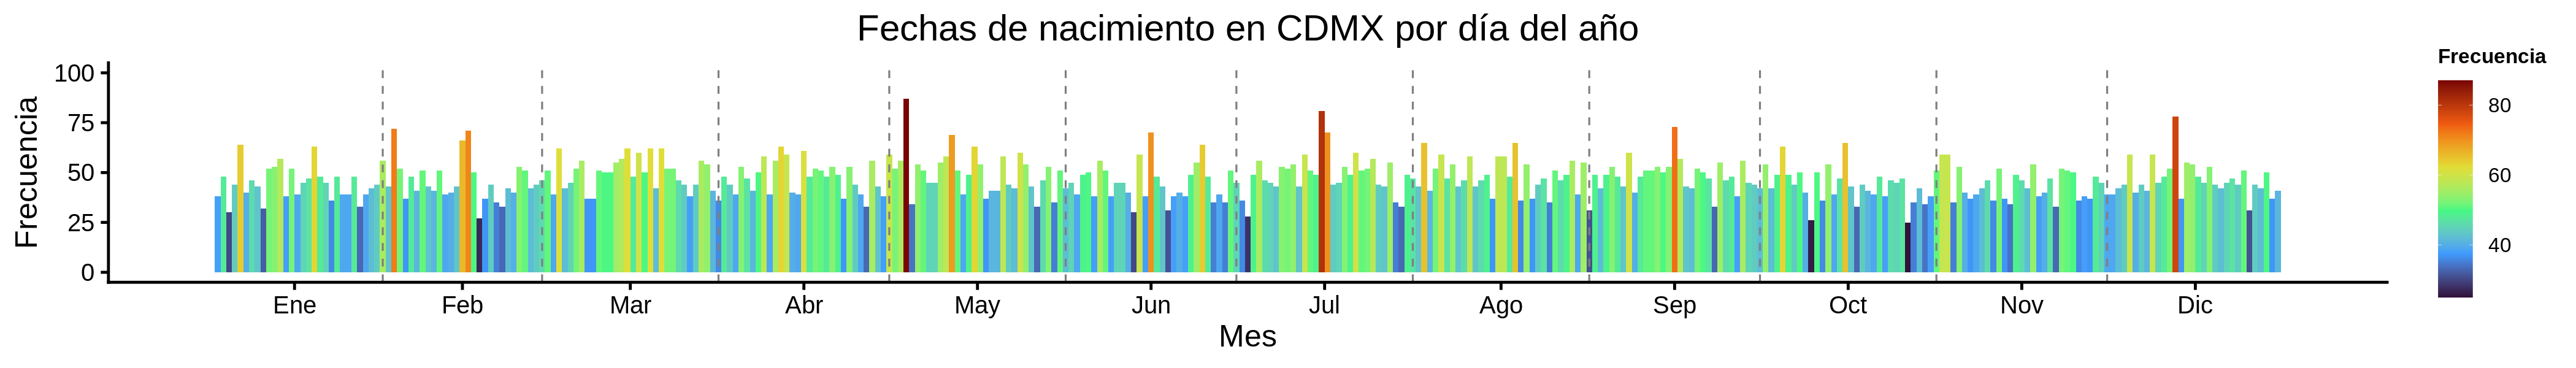

In [ ]:
options(repr.plot.width = 35, repr.plot.height = 5)

grafico <- df %>%
   filter(Nombre_estado == "México") %>%
  ggplot(aes(x = dia_del_año)) +
  geom_histogram(aes(fill = after_stat(count)), alpha = 1, bins = 365, color = NA) +
  scale_fill_viridis_c(option = "turbo", name = "Frecuencia") +
  scale_x_continuous(
    breaks = month_positions,
    labels = months,
    limits = c(1, 365)
  ) +
  geom_vline(xintercept = month_divisions, color = "gray50", size = 0.9, linetype = "dashed") +
  labs(title = "Fechas de nacimiento en CDMX por día del año",
       x = "Mes",
       y = "Frecuencia") +
  theme_classic(base_size = 30) +
  coord_cartesian(ylim = c(0, 100)) +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "right",
    legend.title = element_text(size = 20, face = "bold"),
    legend.text = element_text(size = 20),
    legend.key.height = unit(1.5, "cm"),
    legend.key.width = unit(1.2, "cm"),
    legend.margin = margin(l = 20)
  )

print(grafico)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


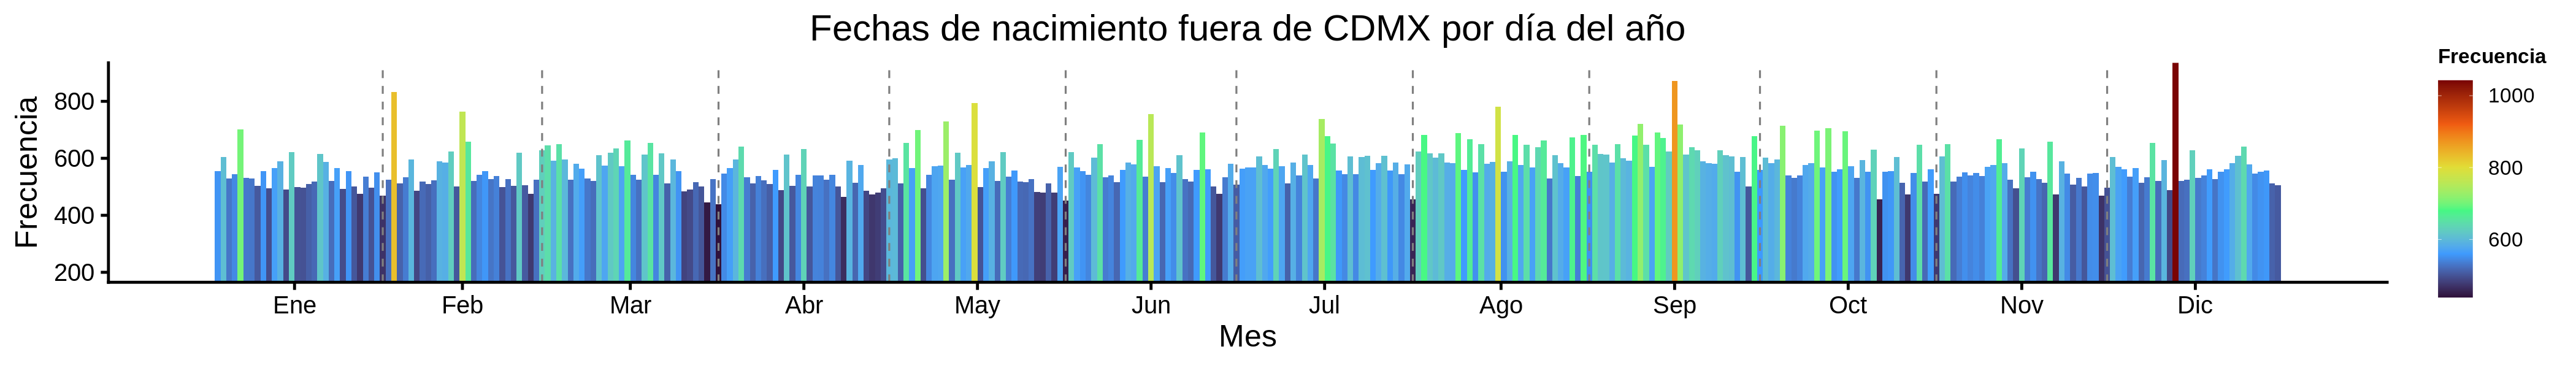

In [ ]:
options(repr.plot.width = 35, repr.plot.height = 5)

grafico <- df %>%
   filter(Nombre_estado != "México") %>%
  ggplot(aes(x = dia_del_año)) +
  geom_histogram(aes(fill = after_stat(count)), alpha = 1, bins = 365, color = NA) +
  scale_fill_viridis_c(option = "turbo", name = "Frecuencia") +
  scale_x_continuous(
    breaks = month_positions,
    labels = months,
    limits = c(1, 365)
  ) +
  geom_vline(xintercept = month_divisions, color = "gray50", size = 0.9, linetype = "dashed") +
  labs(title = "Fechas de nacimiento fuera de CDMX por día del año",
       x = "Mes",
       y = "Frecuencia") +
  theme_classic(base_size = 30) +
  coord_cartesian(ylim = c(200,900)) +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "right",
    legend.title = element_text(size = 20, face = "bold"),
    legend.text = element_text(size = 20),
    legend.key.height = unit(1.5, "cm"),
    legend.key.width = unit(1.2, "cm"),
    legend.margin = margin(l = 20)
  )

print(grafico)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


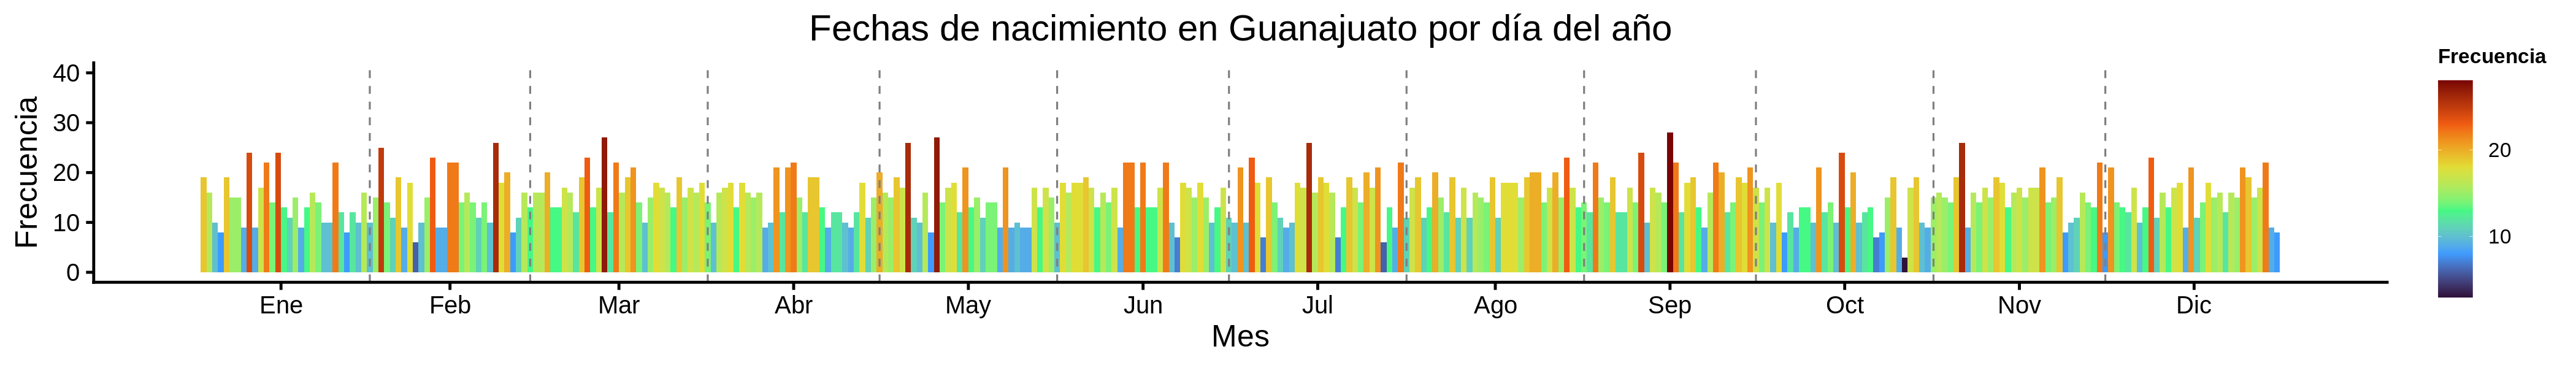

In [ ]:
options(repr.plot.width = 35, repr.plot.height = 5)

grafico <- df %>%
   filter(Nombre_estado == "Guanajuato") %>%
  ggplot(aes(x = dia_del_año)) +
  geom_histogram(aes(fill = after_stat(count)), alpha = 1, bins = 365, color = NA) +
  scale_fill_viridis_c(option = "turbo", name = "Frecuencia") +
  scale_x_continuous(
    breaks = month_positions,
    labels = months,
    limits = c(1, 365)
  ) +
  geom_vline(xintercept = month_divisions, color = "gray50", size = 0.9, linetype = "dashed") +
  labs(title = "Fechas de nacimiento en Guanajuato por día del año",
       x = "Mes",
       y = "Frecuencia") +
  theme_classic(base_size = 30) +
  coord_cartesian(ylim = c(0, 40)) +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "right",
    legend.title = element_text(size = 20, face = "bold"),
    legend.text = element_text(size = 20),
    legend.key.height = unit(1.5, "cm"),
    legend.key.width = unit(1.2, "cm"),
    legend.margin = margin(l = 20)
  )

print(grafico)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


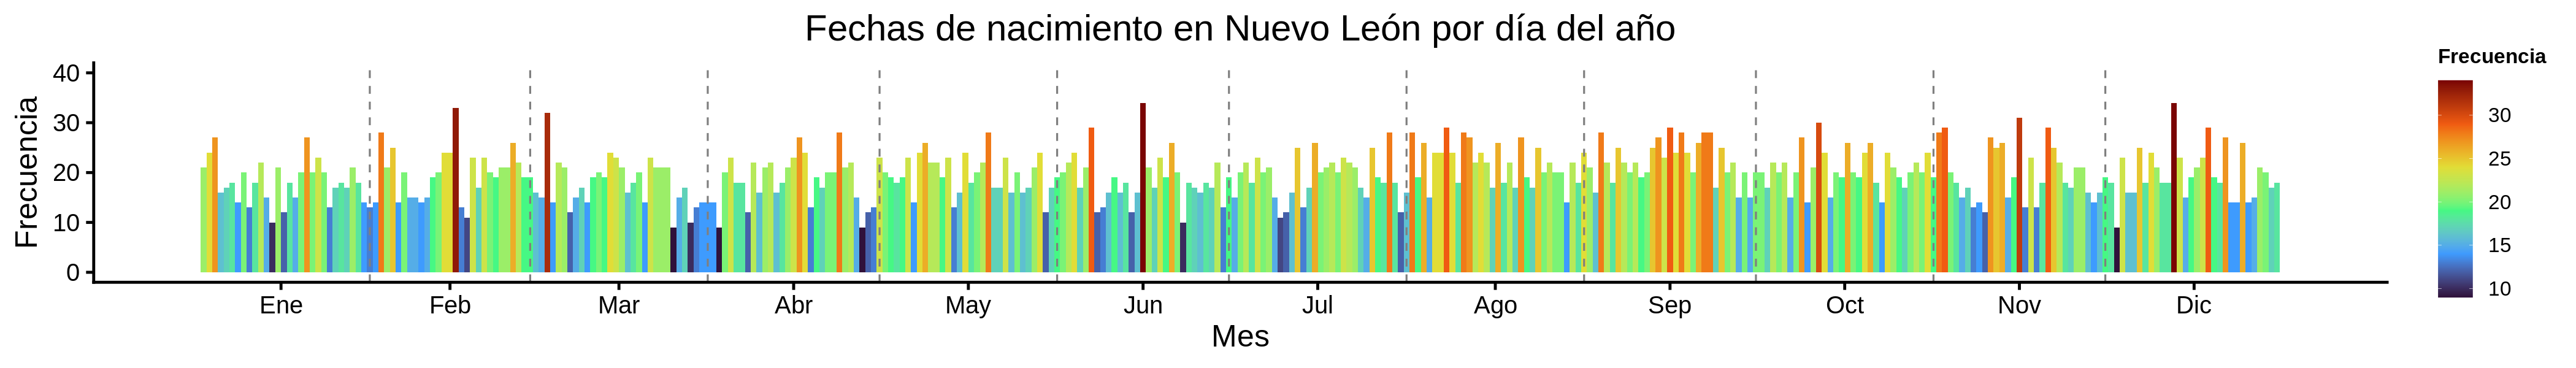

In [ ]:
options(repr.plot.width = 35, repr.plot.height = 5)

grafico <- df %>%
   filter(Nombre_estado == "Nuevo León") %>%
  ggplot(aes(x = dia_del_año)) +
  geom_histogram(aes(fill = after_stat(count)), alpha = 1, bins = 365, color = NA) +
  scale_fill_viridis_c(option = "turbo", name = "Frecuencia") +
  scale_x_continuous(
    breaks = month_positions,
    labels = months,
    limits = c(1, 365)
  ) +
  geom_vline(xintercept = month_divisions, color = "gray50", size = 0.9, linetype = "dashed") +
  labs(title = "Fechas de nacimiento en Nuevo León por día del año",
       x = "Mes",
       y = "Frecuencia") +
  theme_classic(base_size = 30) +
  coord_cartesian(ylim = c(0, 40)) +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "right",
    legend.title = element_text(size = 20, face = "bold"),
    legend.text = element_text(size = 20),
    legend.key.height = unit(1.5, "cm"),
    legend.key.width = unit(1.2, "cm"),
    legend.margin = margin(l = 20)
  )

print(grafico)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


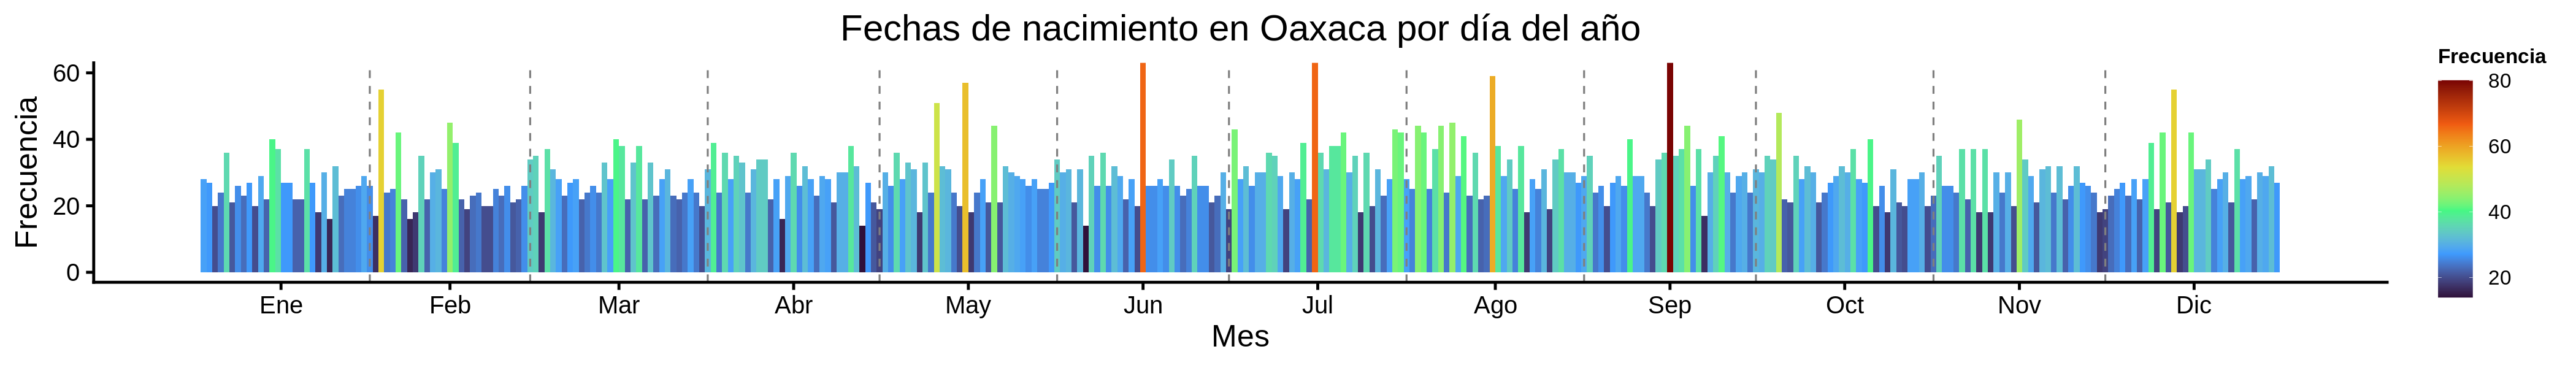

In [ ]:
options(repr.plot.width = 35, repr.plot.height = 5)

grafico <- df %>%
   filter(Nombre_estado == "Oaxaca") %>%
  ggplot(aes(x = dia_del_año)) +
  geom_histogram(aes(fill = after_stat(count)), alpha = 1, bins = 365, color = NA) +
  scale_fill_viridis_c(option = "turbo", name = "Frecuencia") +
  scale_x_continuous(
    breaks = month_positions,
    labels = months,
    limits = c(1, 365)
  ) +
  geom_vline(xintercept = month_divisions, color = "gray50", size = 0.9, linetype = "dashed") +
  labs(title = "Fechas de nacimiento en Oaxaca por día del año",
       x = "Mes",
       y = "Frecuencia") +
  theme_classic(base_size = 30) +
  coord_cartesian(ylim = c(0, 60)) +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "right",
    legend.title = element_text(size = 20, face = "bold"),
    legend.text = element_text(size = 20),
    legend.key.height = unit(1.5, "cm"),
    legend.key.width = unit(1.2, "cm"),
    legend.margin = margin(l = 20)
  )

print(grafico)

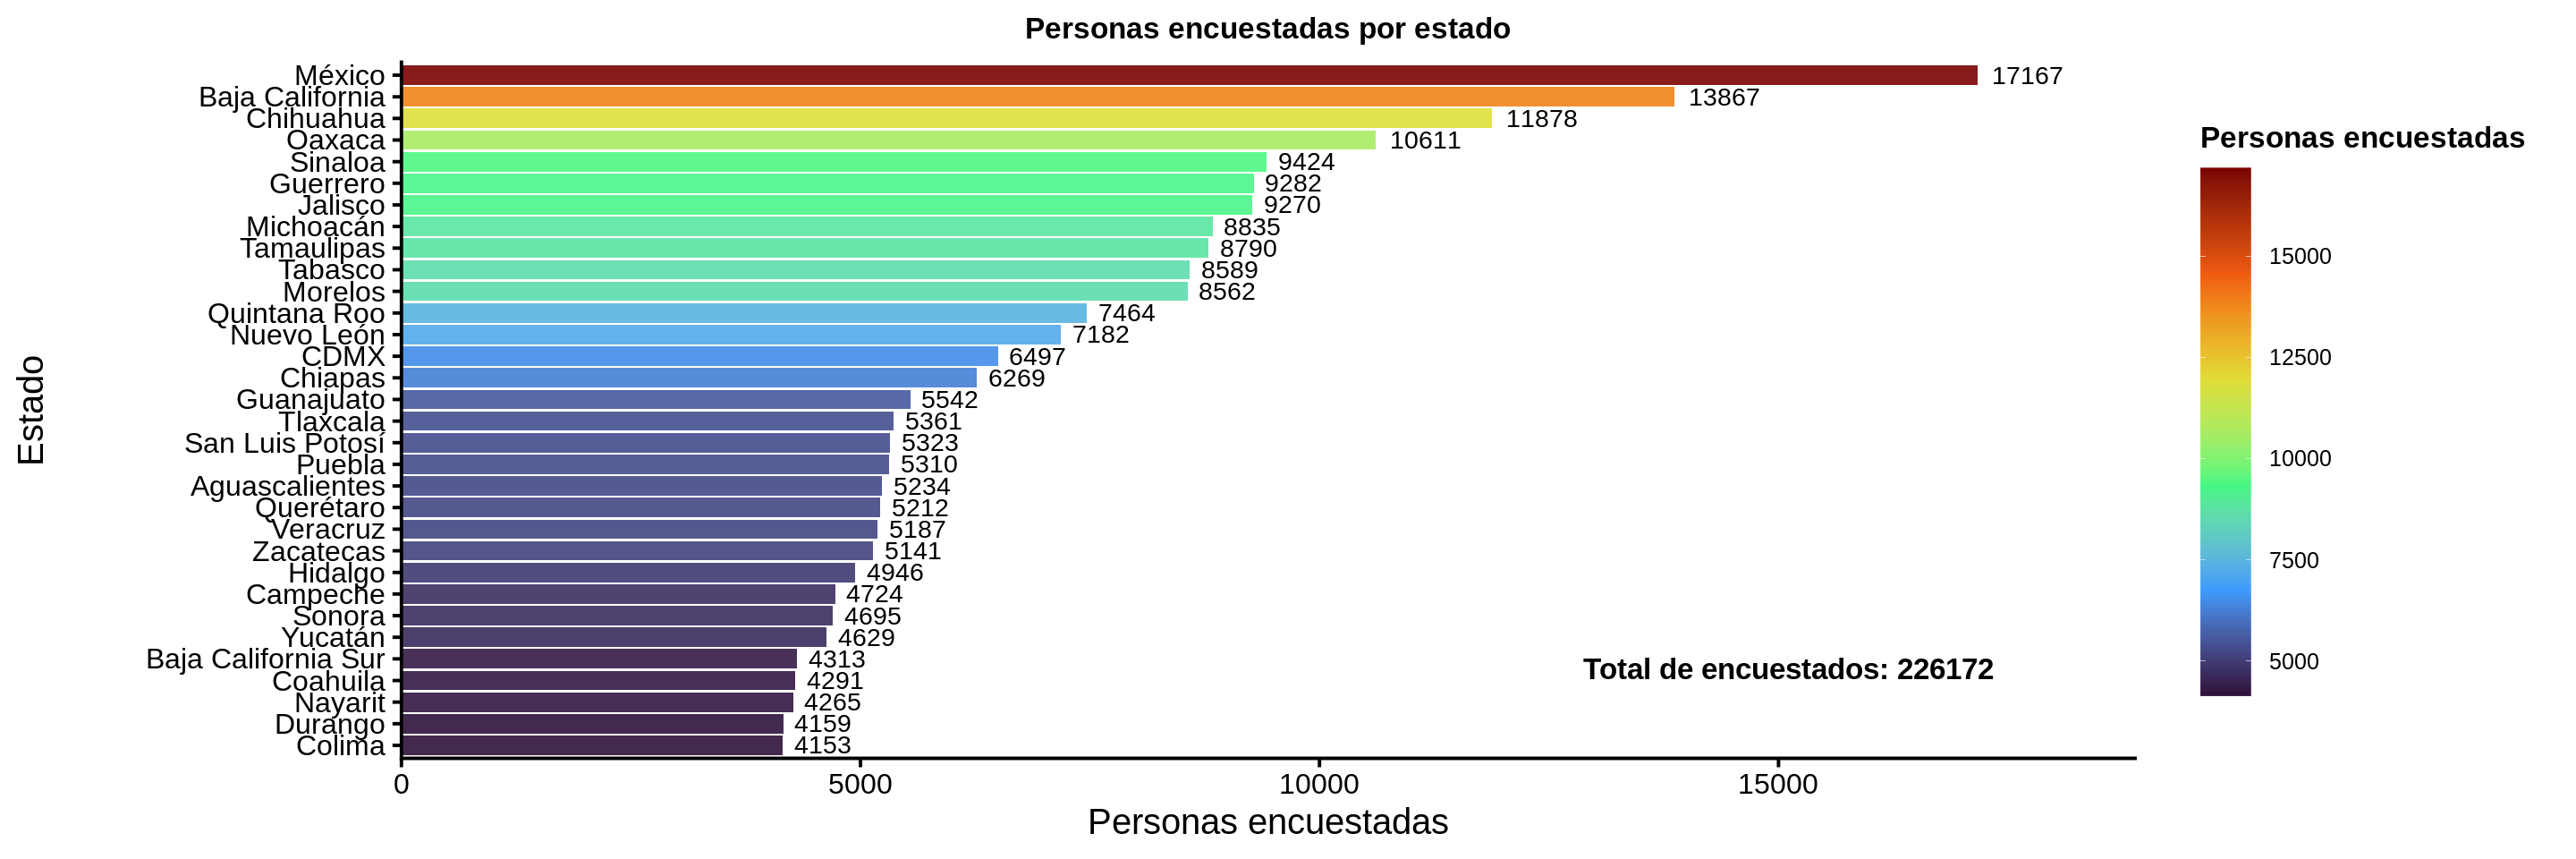

In [ ]:
options(repr.plot.width = 24, repr.plot.height = 8)
grafico <- df %>%
  count(Nombre_estado) %>%
  ggplot(aes(x = reorder(Nombre_estado, n), y = n, fill = n)) +
  geom_col(alpha = 0.9) +
  geom_text(aes(label = n), hjust = -0.2, size = 6, color = "black") +
  scale_fill_viridis_c(option = "turbo") +
  labs(title = "Personas encuestadas por estado",
       x = "Estado",
       y = "Personas encuestadas",
       fill = "Personas encuestadas") +
  theme_classic(base_size = 24) +
  coord_flip() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 20),
    legend.position = "right",
    legend.title = element_text(size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.key.height = unit(2.5, "cm"),
    legend.key.width = unit(1.2, "cm"),
    legend.margin = margin(l = 20)
  ) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  annotate("text", x = 5, y = max(df %>% count(Nombre_estado) %>% pull(n)) * 0.75,
           label = paste("Total de encuestados:", nrow(df)),
           size = 7, color = "black", hjust = 0, vjust = 1, fontface = "bold")

print(grafico)

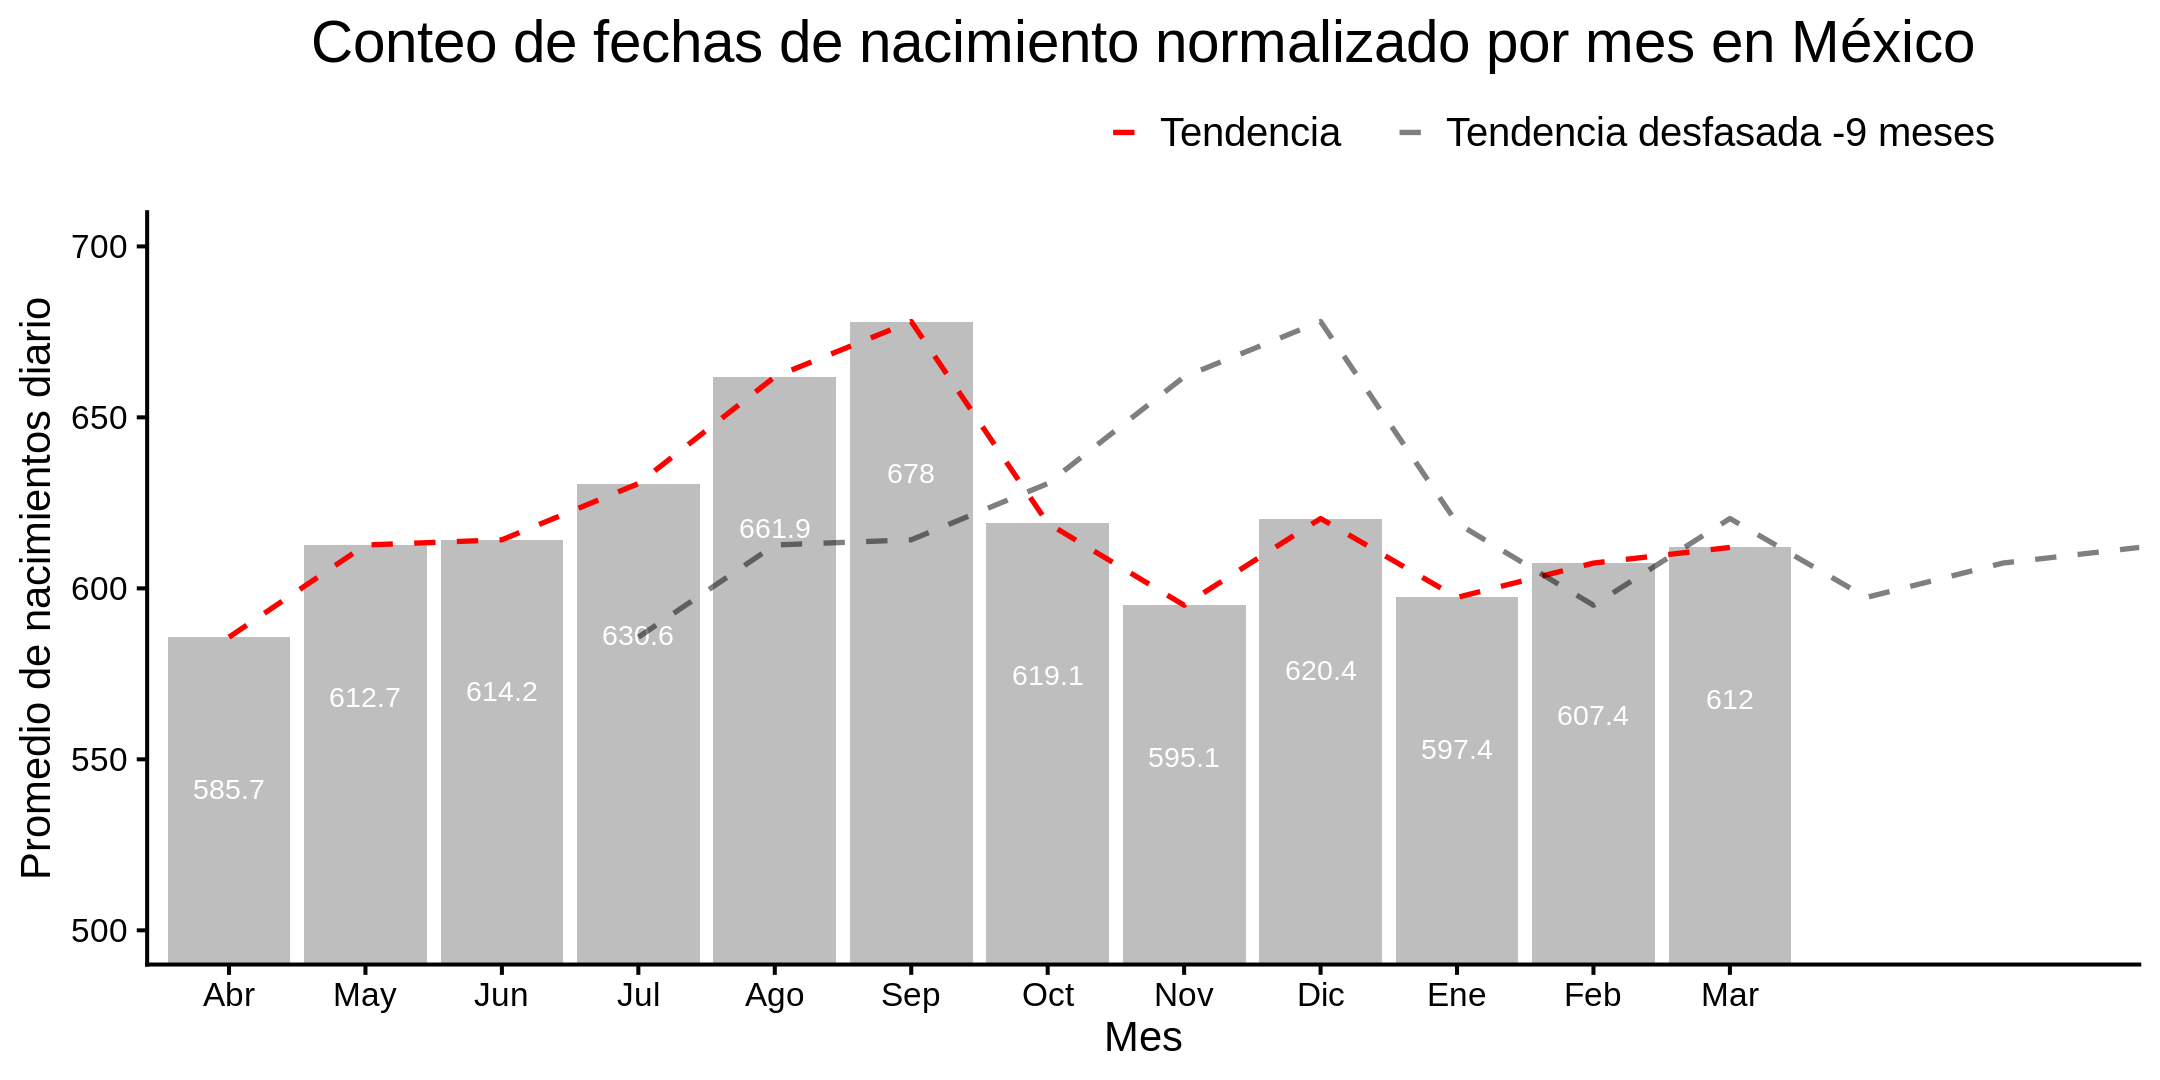

In [ ]:
options(repr.plot.width = 18, repr.plot.height = 9)

orden_meses <- c(4, 5,6, 7,8, 9,10, 11, 12,1, 2, 3)
etiquetas_ordenadas <- months[orden_meses]

grafico <- df %>%
  count(fn_mes) %>%
  mutate(
    n_normalizado = n / days_by_month[fn_mes],
    mes_reordenado = factor(fn_mes, levels = orden_meses, labels = etiquetas_ordenadas)
  ) %>%
  ggplot(aes(x = mes_reordenado, y = n_normalizado)) +
  geom_col(fill = "gray", alpha = 1) +  # Color uniforme, sin borde
  geom_text(aes(label = round(n_normalizado, 1)), vjust = 8.5, size = 6, color = "white") +
  geom_line(aes(group = 1, color = "Tendencia"), linewidth = 1.5, linetype = "dashed") +
  geom_line(aes(group = 1, color = "Tendencia desfasada -9 meses"), linewidth = 1.5, linetype = "dashed",alpha = 0.5,
            position = position_nudge(x = 3)) +
  scale_color_manual(
    name = "Leyenda",
    values = c("Tendencia" = "red",
               "Tendencia desfasada -9 meses" = "black")
  ) +
  coord_cartesian(ylim = c(500, 700)) +
  labs(title = "Conteo de fechas de nacimiento normalizado por mes en México",
       x = "Mes",
       y = "Promedio de nacimientos diario") +
  theme_classic(base_size = 25) +
  theme(
    plot.title = element_text(hjust = 0.5,size = 35),
    legend.position = "top",
    legend.title = element_blank(),
    legend.justification = "right",
    legend.text = element_text(size = 24)
  )
print(grafico)

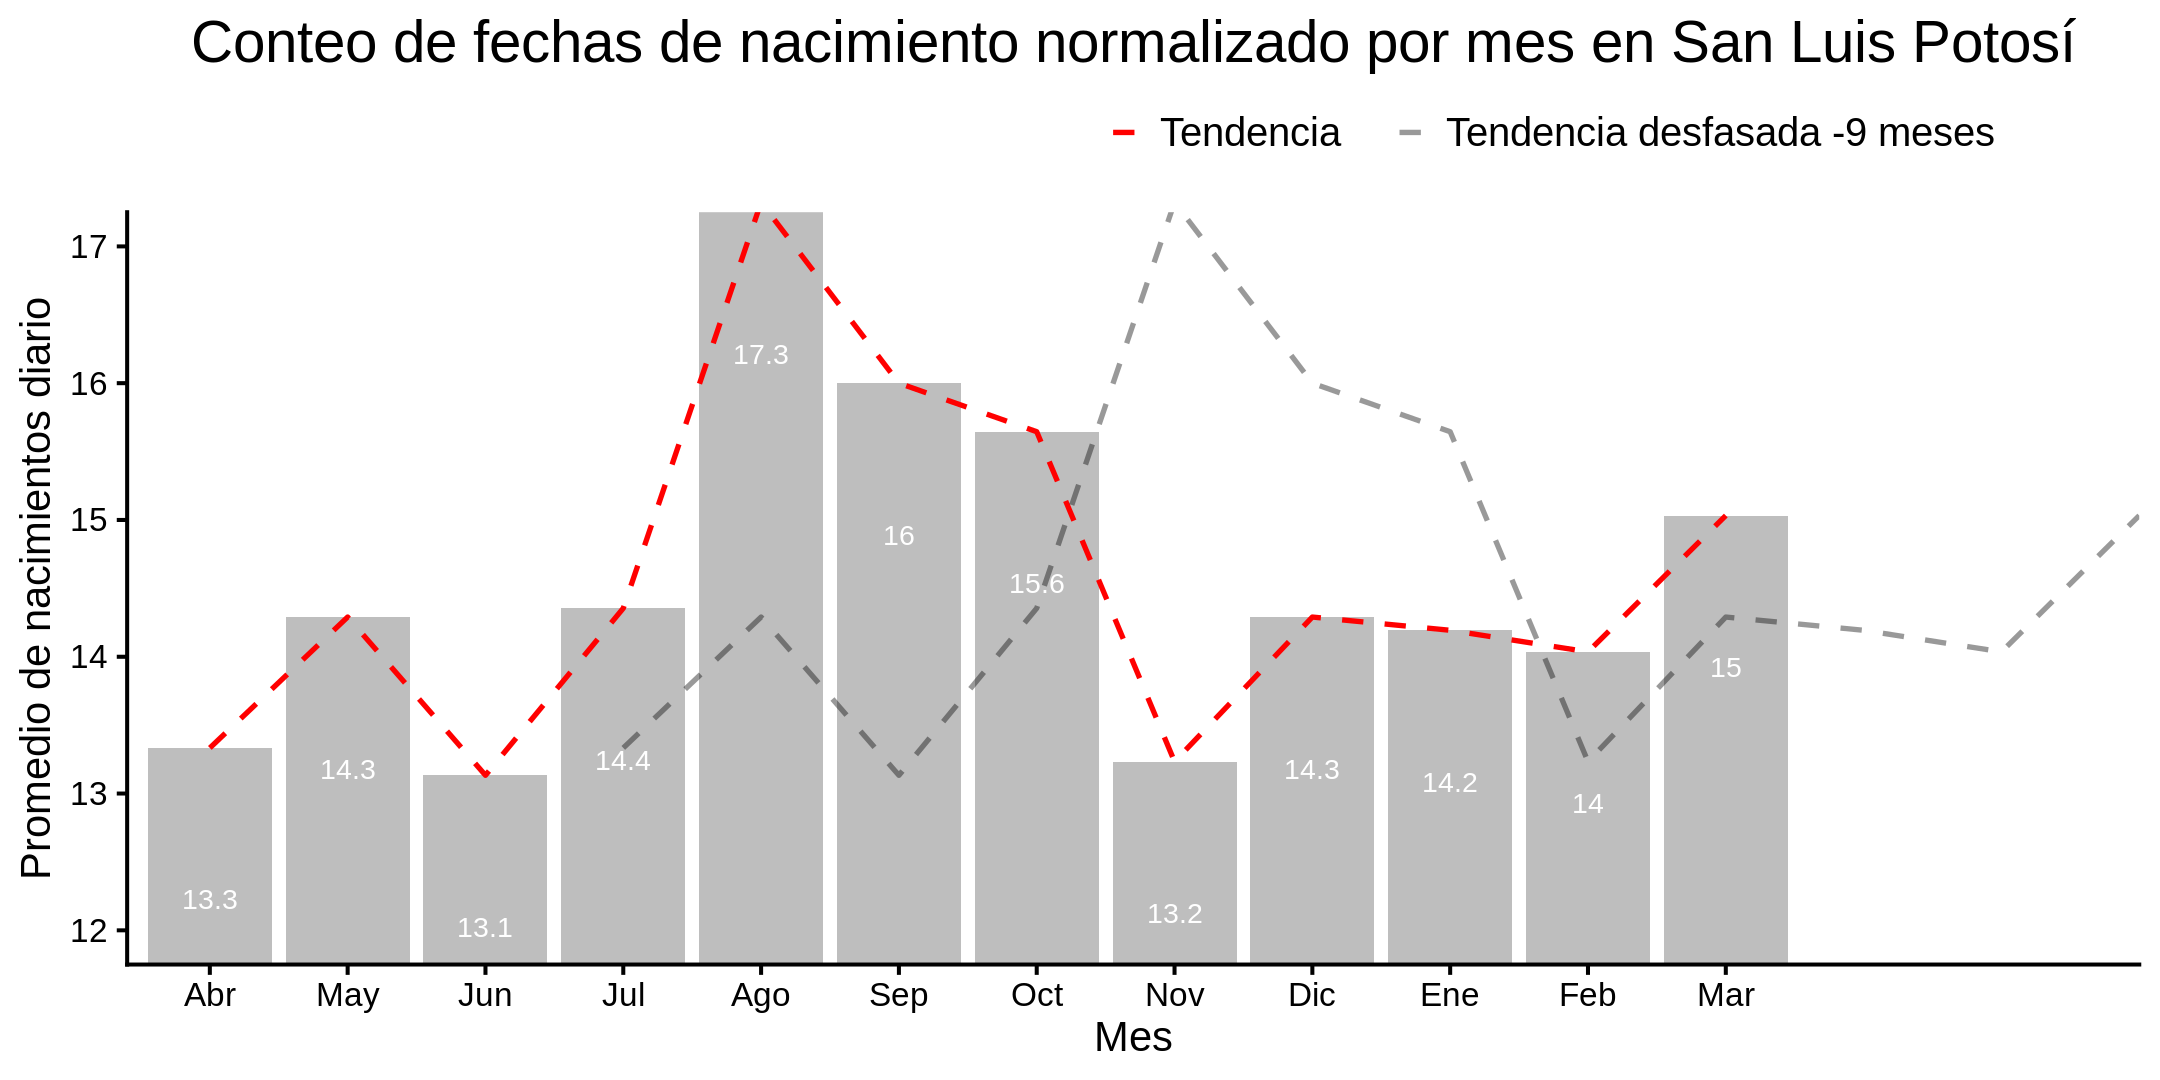

In [ ]:
orden_meses <- c(4, 5,6, 7,8, 9,10, 11, 12,1, 2, 3)
etiquetas_ordenadas <- months[orden_meses]

grafico <- df %>%
  filter(Nombre_estado == "San Luis Potosí") %>%
  count(fn_mes) %>%
  mutate(
    n_normalizado = n / days_by_month[fn_mes],
    mes_reordenado = factor(fn_mes, levels = orden_meses, labels = etiquetas_ordenadas)
  ) %>%
  ggplot(aes(x = mes_reordenado, y = n_normalizado)) +
  geom_col(fill = "gray", alpha = 1) +
  geom_text(aes(label = round(n_normalizado, 1)), vjust = 8.5, size = 6, color = "white") +
  geom_line(aes(group = 1, color = "Tendencia"), linewidth = 1.5, linetype = "dashed") +
  geom_line(aes(group = 1, color = "Tendencia desfasada -9 meses"), linewidth = 1.5, linetype = "dashed",alpha = 0.4,
            position = position_nudge(x = 3)) +
  scale_color_manual(
    name = "Leyenda",
    values = c("Tendencia" = "red",
               "Tendencia desfasada -9 meses" = "black")
  ) +
  coord_cartesian(ylim = c(12, 17)) +
  labs(title = "Conteo de fechas de nacimiento normalizado por mes en San Luis Potosí",
       x = "Mes",
       y = "Promedio de nacimientos diario") +
  theme_classic(base_size = 25) +
  theme(
    plot.title = element_text(hjust = 0.5,size = 35),
    legend.position = "top",
    legend.title = element_blank(),
    legend.justification = "right",
    legend.text = element_text(size = 24)
  )

print(grafico)

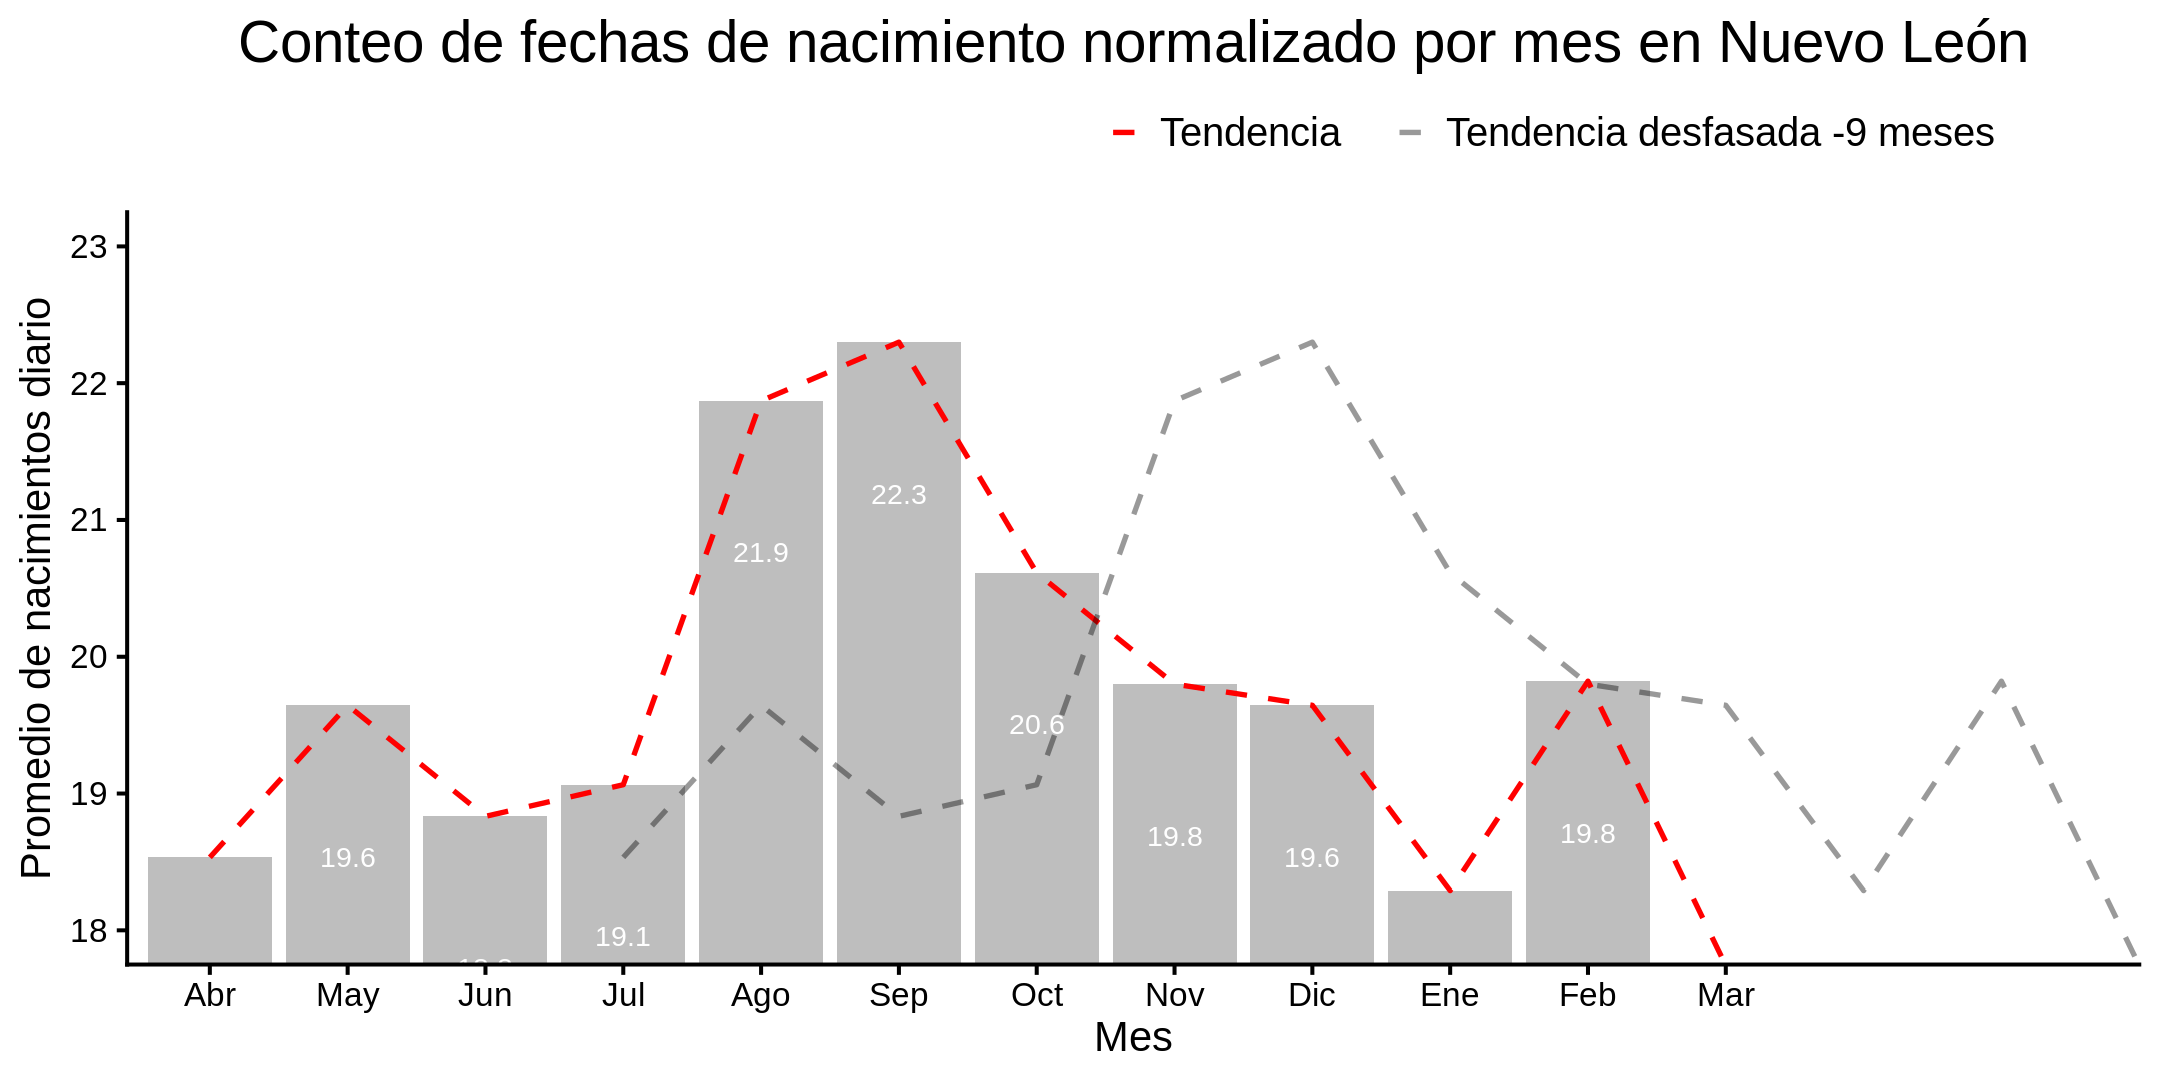

In [ ]:
orden_meses <- c(4, 5,6, 7,8, 9,10, 11, 12,1, 2, 3)
etiquetas_ordenadas <- months[orden_meses]

grafico <- df %>%
  filter(Nombre_estado == "Nuevo León") %>%
  count(fn_mes) %>%
  mutate(
    n_normalizado = n / days_by_month[fn_mes],
    mes_reordenado = factor(fn_mes, levels = orden_meses, labels = etiquetas_ordenadas)
  ) %>%
  ggplot(aes(x = mes_reordenado, y = n_normalizado)) +
  geom_col(fill = "gray", alpha = 1) +
  geom_text(aes(label = round(n_normalizado, 1)), vjust = 8.5, size = 6, color = "white") +
  geom_line(aes(group = 1, color = "Tendencia"), linewidth = 1.5, linetype = "dashed") +
  geom_line(aes(group = 1, color = "Tendencia desfasada -9 meses"), linewidth = 1.5, linetype = "dashed",alpha = 0.4,
            position = position_nudge(x = 3)) +
  scale_color_manual(
    name = "Leyenda",
    values = c("Tendencia" = "red",
               "Tendencia desfasada -9 meses" = "black")
  ) +
  coord_cartesian(ylim = c(18, 23)) +
  labs(title = "Conteo de fechas de nacimiento normalizado por mes en Nuevo León",
       x = "Mes",
       y = "Promedio de nacimientos diario") +
  theme_classic(base_size = 25) +
  theme(
    plot.title = element_text(hjust = 0.5,size = 35),
    legend.position = "top",
    legend.title = element_blank(),
    legend.justification = "right",
    legend.text = element_text(size = 24)
  )

print(grafico)

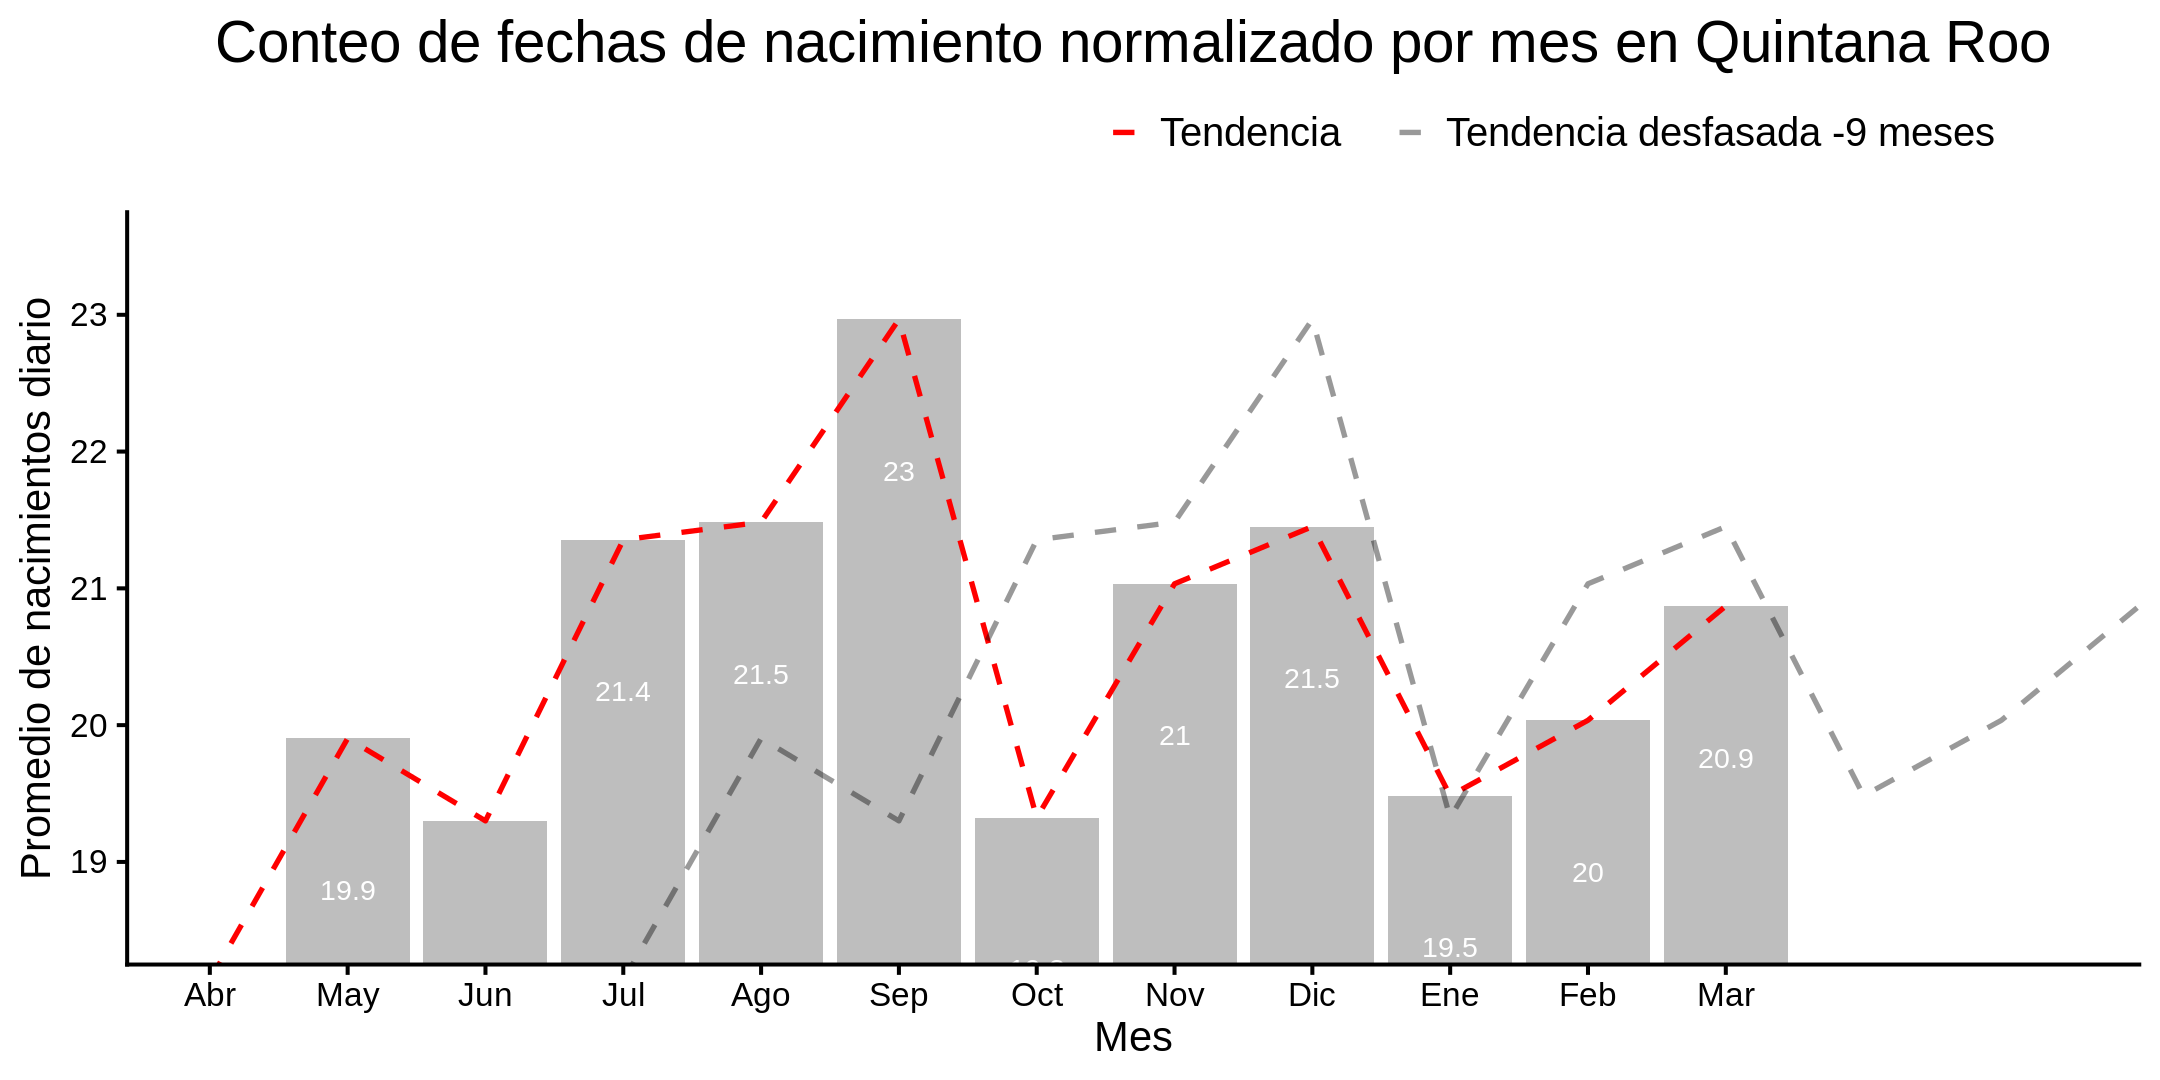

In [ ]:
orden_meses <- c(4, 5,6, 7,8, 9,10, 11, 12,1, 2, 3)
etiquetas_ordenadas <- months[orden_meses]

grafico <- df %>%
  filter(Nombre_estado == "Quintana Roo") %>%
  count(fn_mes) %>%
  mutate(
    n_normalizado = n / days_by_month[fn_mes],
    mes_reordenado = factor(fn_mes, levels = orden_meses, labels = etiquetas_ordenadas)
  ) %>%
  ggplot(aes(x = mes_reordenado, y = n_normalizado)) +
  geom_col(fill = "gray", alpha = 1) +
  geom_text(aes(label = round(n_normalizado, 1)), vjust = 8.5, size = 6, color = "white") +
  geom_line(aes(group = 1, color = "Tendencia"), linewidth = 1.5, linetype = "dashed") +
  geom_line(aes(group = 1, color = "Tendencia desfasada -9 meses"), linewidth = 1.5, linetype = "dashed",alpha = 0.4,
            position = position_nudge(x = 3)) +
  scale_color_manual(
    name = "Leyenda",
    values = c("Tendencia" = "red",
               "Tendencia desfasada -9 meses" = "black")
  ) +
  coord_cartesian(ylim = c(18.5, 23.5)) +
  labs(title = "Conteo de fechas de nacimiento normalizado por mes en Quintana Roo",
       x = "Mes",
       y = "Promedio de nacimientos diario") +
  theme_classic(base_size = 25) +
  theme(
    plot.title = element_text(hjust = 0.5,size = 35),
    legend.position = "top",
    legend.title = element_blank(),
    legend.justification = "right",
    legend.text = element_text(size = 24)
  )

print(grafico)

#Ejercicio 3

In [ ]:
set.seed(6170)     #semilla

n_experimentos <- 10000   # experimentos
n <- 100         # vueltas

per_tiempo_ganancia <- replicate(n_experimentos, {
  pasos <- rbinom(n, 1, 0.5) * 2 - 1
  Ct <- cumsum(pasos)                   # Ct
  mean(Ct > 0)                          # % del tiempo con racha positiva
})

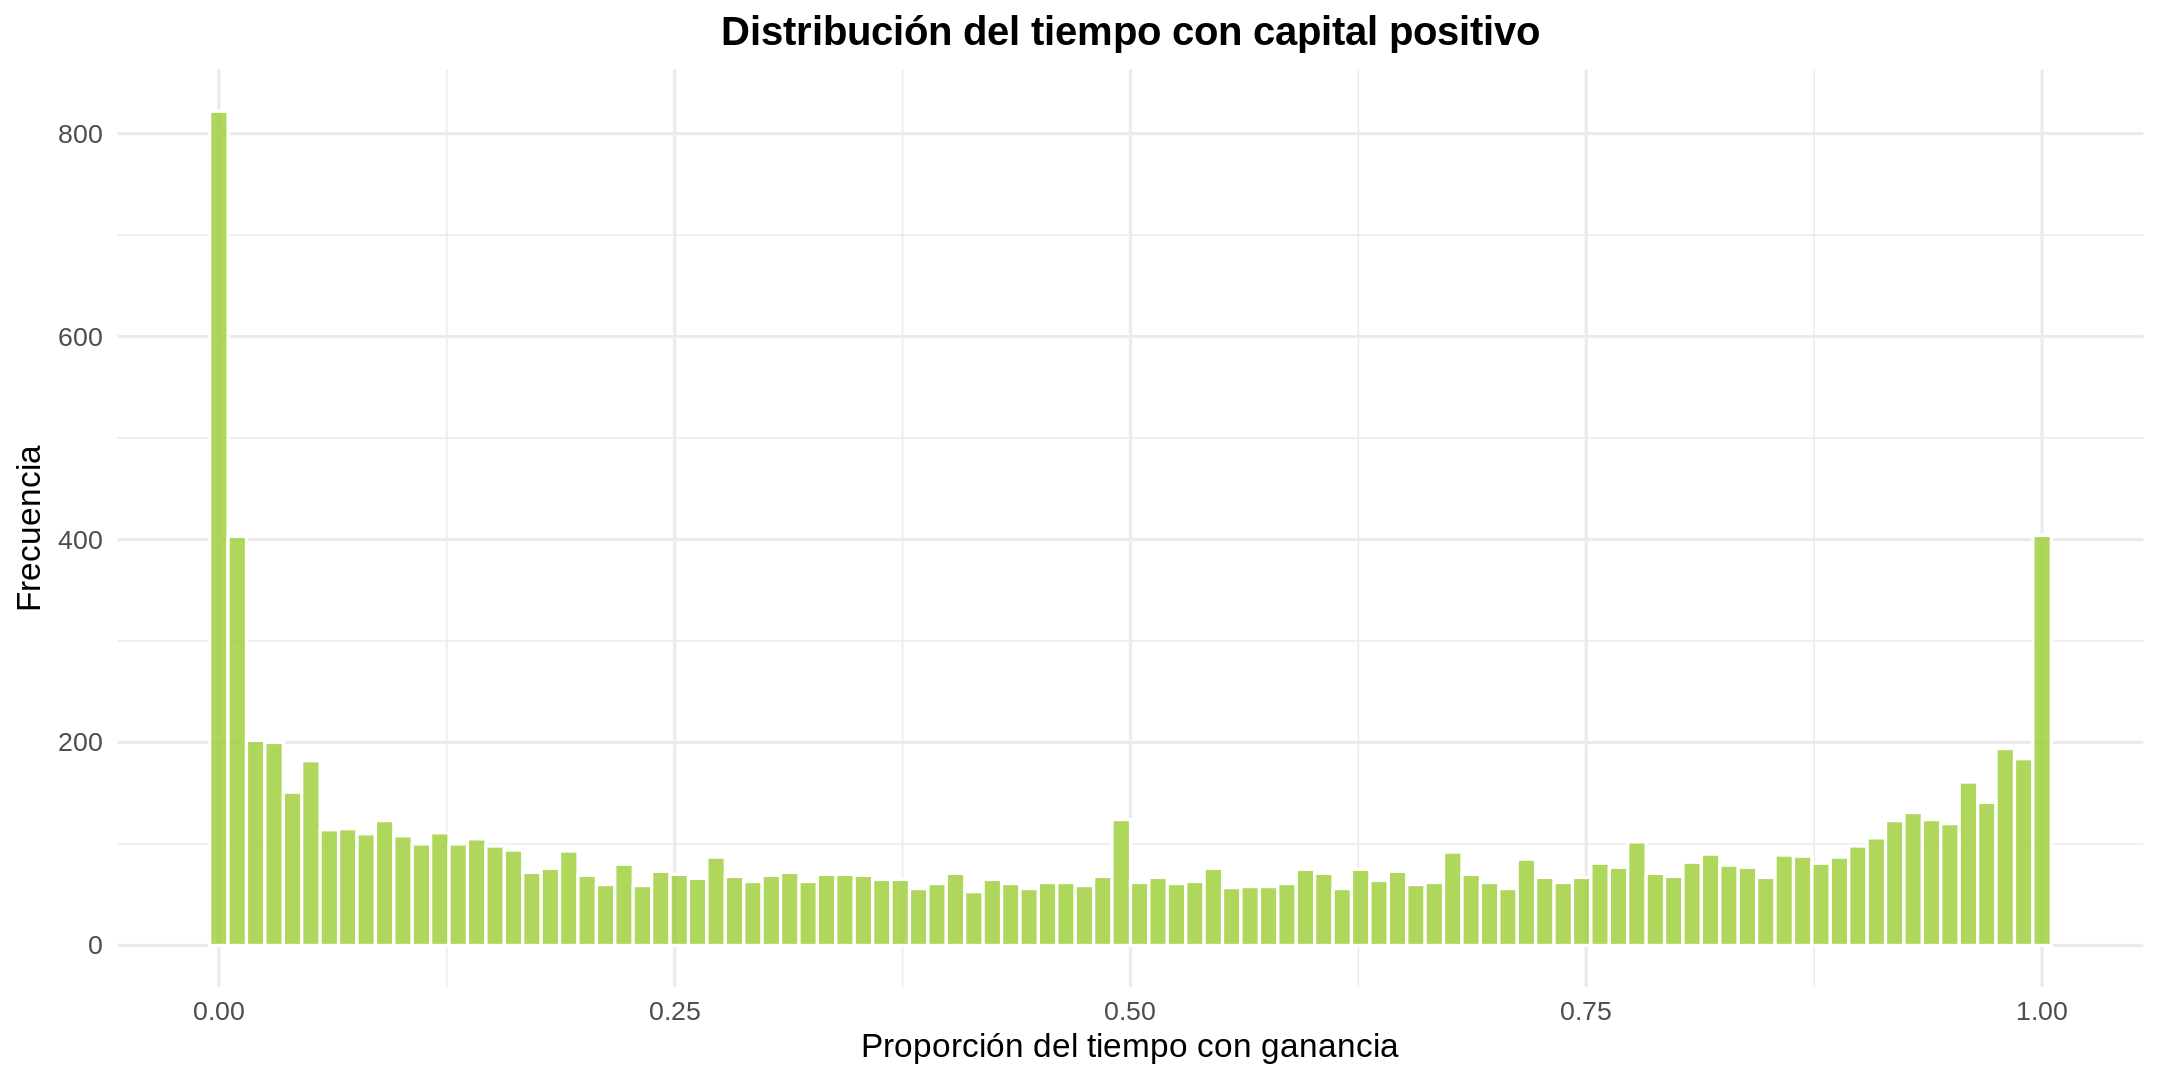

In [ ]:
options(repr.plot.width = 18, repr.plot.height = 9)
df <- data.frame(proporcion = per_tiempo_ganancia)

ggplot(df, aes(x = proporcion)) +
  geom_histogram(
    bins = 100,
    fill = "yellowgreen",
    color = "white",
    alpha = 0.8
  ) +
  labs(
    title = "Distribución del tiempo con capital positivo",
    x = "Proporción del tiempo con ganancia",
    y = "Frecuencia"
  ) +
  theme_minimal(base_size = 20) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold")
  )
